# Neural Networks Assignment, 2025 A2 <ignore>
## Overview
In this assessment, you will be asked to carry out three tasks. The first task involves building and training a simple CNN-based classifier for the Fashion MNIST dataset, and demonstrating the effectiveness of a technique to improve gradient flow. The second task involves building and training an unconditional GAN to generate images that look like those in the Fashion MNIST dataset, and using the discriminator to investigate the quality of the generated images. The third task involves augmenting the GAN to improve the generated images in some way.

## Instructions
### Code and Markdown cells
All of your report, including code and Markdown/text, ***must*** be written up in ***this*** notebook. Please make sure you change the title of this file so that XXXXXX is replaced by your candidate number. You can use code cells, where provided, to write code to implement, train, test, and analyse your NNs, as well as to generate figures to plot data and the results of your experiments. If you wish to add more code cells, you may do so immediately after the code cells that have been provided, but do not add any code cells anywhere else in this file. You must use the Markdown/text cells that are provided for writing the three report sections, one for each Task. These Markdown cells have "*Replace this text with your report for Task X*" in italics. Please replace that text with your own text. So that we can mark your reports with greater consistency, please ***do not***:

* add any of your own Markdown cells.
* rearrange the sequence of cells in this notebook.
* delete any cells, including the ones explaining what you need to do.

### Plotting figures
All plots of data ***must*** be produced as output from a code cell. Any plots that have been imported as images, rather than being the output of a plot function (such as that provided by matplotlib) will not receive marks. This is to ensure that you did the work to produce that plot. All figures should have an accompanying caption that states the Figure number and a detailed description of what the figure shows (see the guidenace in the file ```useful_code_for_figures_equations.ipynb```). 

### Writing code
Where relevant in your written report, e.g. when describing your methods, indicate where in your code the methods are implemented, including  the cell and line numbers (if you use VSCode, these are visible in the bottom right corner of the window). You might say, for example, "_layers 1-4 used 3x3 convolutional filters with a stride of 1 and padding of 1 (cell 5, line 30)_".  Please provide verbose comments throughout your code so that it is easy for us to interpret what you are attempting to achieve. Long comments are useful at the beginning of a block of code. Short comments, e.g. to explain the purpose of a new variable, or one of several steps in some analyses, are useful on every few lines of code, if not on every line. Please do not use the code cells for writing verbose responses to subtasks, which should instead be written in the provided Markdown cells.

# TASK 1 <ignore>

Methodology
Task 1 required a 5-layer CNN for Fashion-MNIST classification, taking 1x28×28 greyscale images and producing a 10-class output. I implemented two models: a baseline CNN and a second version with Batch Normalisation (BN).
The NN used five 3×3 convolutional layers with stride 1 and padding 1, increasing channel depth from 32 to 64, 128, 256 and 512. This follows lecture material showing that stacked small filters are effective because they increase the receptive field gradually while keeping the architecture simple and parameter-efficient. Max-pooling was applied after earlier blocks to reduce spatial dimensions and computation. whilst retaining salient features.
ReLU was used after each convolution. Sigmoid and tanh saturate and cause small derivatives that weaken backpropagated gradients. ReLU maintains stronger gradient propagation for positive activations and typically learns much faster in deep CNNs. The model depth was sufficient for optimisation stability to matter, especially when comparing the baseline model against the BN version.
Global Average Pooling (GAP) followed by 30% dropout and a final linear layer are used to reduce parameter count before classification. GAP is a replacement to large fully connected heads by averaging each final feature map. This produces a compact representation that is less parameter heavy and easier to generalise. Dropout with p=0.3 was included before the final classifier to reduce co-adaptation between neurons and help limit overfitting.
The input data were converted to tensors and normalised using the Fashion-MNIST mean and standard deviation. Standardisation improves optimisation by making activations more stable across layers. The original 60000 image training split was divided into 80% training and 20% validation examples using a fixed seed of 42 for reproducibility. The standard 10000 image test set was kept separate for final evaluation after training.
A learning-rate search was then carried out over five Adam LR: 10^−4, 5×10^−4, 10^−3, 5×10^−3, and 10^−2. Adam was chosen because it is a strong practical default that combines momentum with adaptive per-parameter updates, making it robust when curvature differs across parameters. The best learning rate was selected using validation accuracy after five epochs. That value was used for both the baseline and BN experiments to ensure fairness in comparisons.
To evaluate the effect of BN, both models were trained for 15 epochs. The training and validation loss and accuracy were recorded after each epoch. The BN layers were inserted after each convolution and before ReLU. BN improves gradient flow, allows higher learning rates, reduces sensitivity to __init__ialisation, and also acts as an effect.

Results
The learning-rate search in Figure 1 showed Adam 5×10^−3 produced the highest validation accuracy at the end of the short search procedure. Smaller learning rates, especially 10^−4, improved slowly, suggesting under-aggressive parameter updates. 10^−2 indicates instability across epochs, meaning the optimisation steps were sometimes too large. This behaviour fits the treatment of optimisation, where the step size must be large enough for efficient progress but not too large that updates overshoot useful regions of the loss surface.

Figure 2A shows the training and validation cross-entropy loss over 15 epochs for both the baseline and BN models. The BN model's loss decreases more steeply in early epochs and reaches a lower final training loss than the baseline, indicating faster and more effective optimisation.

The baseline model finished with training accuracy of 91.3% and validation accuracy around 89.4%, whereas the BN model reached about 98.2% training accuracy and 92.4% validation accuracy. The BN model validation accuracy reached above 91% in epoch 5. The baseline model does not have similar convergence, meaning it finds the optimal solution slower compared to that of BN model. 

In the baseline model, gradients pass through five convolutional layers without intermediate normalisation, so the scale of activations drifts during training and makes optimisation harder. In contrast, BN normalises batch activations and then learns a useful rescaling, which stabilises the distribution seen by later layers and makes parameter updates more reliable.

Figure 2B shows a widening gap between training and validation performance in the BN model after roughly epoch 8. Although BN improved optimisation and final validation accuracy, the training accuracy continued to rise more strongly than validation accuracy, indicating some overfitting. Dropout appears to have limited this effect rather than eliminating it entirely, which is reasonable given the model capacity and the relatively simple dataset. A plausible improvement would be stopping training earlier or adding data augmentation.

Figure 3A shows the overall test accuracy of both models on the held-out test set. The BN model achieved 92.0% test accuracy compared to 89.1% for the baseline. This confirms the improvement seen during validation (Figure 2A & 2B) and demonstrating that the benefit of BN generalises beyond the training data.

Figure 3B indicates that some Fashion-MNIST classes were easier than others. Classes with clearer visual structure, such as footwear or bags, generally achieved stronger class-wise performance. Upper garments with similar silhouettes were weaker. These classes share overlapping silhouettes and texture patterns, making their feature representations harder to separate.

The confusion matrix in Figure 4 supports this interpretation. Misclassifications are concentrated among similar clothing categories, suggesting that the model struggled with inter class boundaries. High overall accuracy does not mean all categories are easy to distinguish.

Discussion
Overall, the CNN demonstrated that Batch Normalisation improves the classifier. BN provides a modest increase in final validation accuracy, faster convergence and more stable optimisation. In that sense, BN was an effective technique for the required comparison.

The architecture choices were intentionally conservative. Small 3×3 convolutions, ReLU nonlinearities, max pooling and Global Average Pooling provided a strong baseline without introducing unnecessary complexity.

However, the experiment also showed that optimisation does not equal generalisation. The BN model achieved very high training accuracy, but showed a gap between training validation accuracy. The BN model was optimisation-limited early in training and more generalisation-limited later in training. This explains the quick convergence early in training, while the lower per-class accuracy observed for shirt-like garments (Figure 3B) reflects the difficulty caused by feature similarity between visually similar classes.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Use GPU if CPU not available.
# GPU runs training and testing significantly faster than CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Fashion MNIST has 10 clothing categories, each mapped to an integer index
CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# ToTensor() converts an image to a float32 tensor in the range [0, 1] with shape (C, H, W) = (1, 28, 28).
# Normalise() subtracts the dataset channel mean and divides bythe channel std , giving a zero-mean, unit-std inputs.
# stabilises gradient magnitudes and speeds up convergence.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalise(mean=(0.2860,), std=(0.3530,))
])

# FashionMNIST 60 000 training images and 10 000 test images.
# download and fetches the raw files from the internet.
full_train = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Reserve 20 % of the 60 000 training images as a validation set.
# The validation set is used during training to monitor generalisation.
# manual_seed=42 ensures the same 48k/12k split every time,
# making results reproducible across different machines.
n_train = int(0.8 * len(full_train))
n_val = len(full_train) - n_train
train_set, val_set = random_split(full_train, [n_train, n_val],
generator=torch.Generator().manual_seed(42))

# DataLoader wraps a dataset and yields mini-batches of images and labels pairs.
# shuffle = true to randomise each epoch, preventing caching of the order of examples
BATCH_SIZE = 64
training_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
validation_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
testing_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)}  |  Val: {len(val_set)}  |  Test: {len(test_set)}")


Using device: cpu
Train: 48000  |  Val: 12000  |  Test: 10000


In [ ]:
# A 5-layer convolutional neural network (CNN) for 10 class classification with 1x28×28 greyscale Fashion MNIST images.
#   • All convolutional filters are 3×3 with padding=1,preventing spatial shrinkage and preserving the 28×28 input size until pooling layers.
#   • The number of feature maps doubles each layer (32→64→128→256→512),
#   • MaxPool2d(2,2) halves the spatial size after layers 1, 2, and 4.
#   • AdaptiveAvgPool2d(1) (Global Average Pooling) replaces a large fully
#     connected layer.
#   • averaging each feature map to a single value, reducing
#     the 512-channel map to a 512-d vector regardless of input size, acting as spatial regulariser.
#   • BatchNorm is applied conditionally, same class is used in both BatchNorm and baseline.
#   • Dropout 30% reduction before the final linear layer reduces co-adaptation of neurons and improves generalisation.

class CNN(nn.Module):
    def __init__(self, use_bn=True):
        """Parameters use_bn : bool
            If bool = True, a BatchNorm2d layer is inserted after each Conv2d.
            Set bool = False to run the baseline model without batch normalization.
        """
        super().__init__()
        self.use_bn = use_bn

        # CNN layers
        # Each Conv2d is paired with a BatchNorm2d layer that is applied only when use_bn=True. 
        # The number of output channels (feature maps) increases with depth to capture increasingly complex features.

        # Layer 1 learns low-level edge and gradient detectors (input: 1×28×28)
        self.conv1 = nn.Conv2d(1,   32,  kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Layer 2 learns corner and texture detectors
        self.conv2 = nn.Conv2d(32,  64,  kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Layer 3 learns simple shape and pattern detectors
        self.conv3 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Layer 4 learns part-level features such as sleeves, collars, and shoe tongues
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Layer 5 learns object-level representations such as whole shirts, shoes, and bags
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)

        # Pooling, regularisation, and classification
        self.pool = nn.MaxPool2d(2, 2)

        # Global Average Pooling collapses each feature map to a scalar,
        # producing a compact 512-d descriptor.
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Drop 30 % of units during training to preventing overfitting in the final fully connected layer.
        self.drop = nn.Dropout(0.3)

        # Final linear layer maps the 512-d descriptor to 10 class logits.
        self.fc = nn.Linear(512, 10)

    def forward(self, x):
        """
        Forward passes, and input what shape is x (batch, 1, 28, 28).
        """
        # Layer 1: conv → BN → ReLU → MaxPool
        # After pooling batch = [32, 14, 14]
        x = self.conv1(x)
        #normalisation before activation, which improves training stability and convergence speed.
        if self.use_bn: x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        # Layer 2: conv → BN → ReLU → MaxPool
        # After pooling batch = [64, 7, 7]
        x = self.conv2(x)
        if self.use_bn: x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)

        # Layer 3: conv → BN → ReLU  (no pooling, since spatial size too small)
        # After: batch = [128, 7, 7]
        x = self.conv3(x)
        if self.use_bn: x = self.bn3(x)
        x = F.relu(x)

        # Layer 4: conv → BN → ReLU → MaxPool
        # After pooling batch = [256, 3, 3]
        x = self.conv4(x)
        if self.use_bn: x = self.bn4(x)
        x = F.relu(x)
        x = self.pool(x)

        # Layer 5: conv → BN → ReLU
        # After: batch = [512, 3, 3]
        x = self.conv5(x)
        if self.use_bn: x = self.bn5(x)
        x = F.relu(x)

        # Global Average Pooling: batch = [512, 3, 3] → batch = [512, 1, 1]
        x = self.gap(x)
        # Flatten to 1-D descriptor: batch = [512, 1, 1] → batch = [512]
        x = x.view(x.size(0), -1)

        # Dropout then linear classifier: batch = [512] → batch = [10]
        # softmax is applied internally by CrossEntropyLoss
        x = self.drop(x)
        x = self.fc(x)
        return x

In [ ]:
# train_one_epoch() and evaluate() are reusable functions for training and evaluating models.
def train_one_epoch(model, loader, criterion, optimizer):
    """
    Run one full pass over the training data, updating model weights.
    mini batches required:
      •  Zero the accumulated gradients from the previous step.
      •  Forward pass to compute predictions and loss.
      •  Backward pass to compute gradients via backpropagation.
      •  Optimiser step to update weights using the computed gradients.
    Returns:
        avg_loss : float, the mean cross-entropy loss over all training samples
        accuracy : float, the fraction of correctly classified training samples
    """
    model.train()

    # accumulators for loss, correct predictions, and total sample count
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        # moves the mini-batch tensors to the GPU.
        images, labels = images.to(device), labels.to(device)

        # clear gradients from the previous batch
        # forward pass → (batch, 10) logits
        # scalar cross-entropy loss
        # compute ∂ loss/∂ weights for every parameter
        # update weights: w ← w − lr · ∂loss/∂w
        optimizer.zero_grad()          
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Accumulate statistics for each epoch
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    """
    using test data to evaluate the performance of the model after training.
    torch.no_grad() disables gradient computation entirely
    Returns:
        avg_loss: float, the mean cross-entropy loss over all samples in loader
        accuracy: float, the fraction of correctly classified samples
    """
    model.eval()

    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total



LR = 0.0001
  epoch 1/5  val acc: 88.4%
  epoch 2/5  val acc: 90.1%
  epoch 3/5  val acc: 90.5%
  epoch 4/5  val acc: 90.1%
  epoch 5/5  val acc: 90.9%

LR = 0.0005
  epoch 1/5  val acc: 89.8%
  epoch 2/5  val acc: 90.2%
  epoch 3/5  val acc: 90.9%
  epoch 4/5  val acc: 91.8%
  epoch 5/5  val acc: 91.6%

LR = 0.001
  epoch 1/5  val acc: 88.8%
  epoch 2/5  val acc: 88.1%
  epoch 3/5  val acc: 92.2%
  epoch 4/5  val acc: 91.9%
  epoch 5/5  val acc: 91.2%

LR = 0.005
  epoch 1/5  val acc: 88.7%
  epoch 2/5  val acc: 90.5%
  epoch 3/5  val acc: 89.7%
  epoch 4/5  val acc: 91.6%
  epoch 5/5  val acc: 92.1%

LR = 0.01
  epoch 1/5  val acc: 89.0%
  epoch 2/5  val acc: 88.6%
  epoch 3/5  val acc: 90.9%
  epoch 4/5  val acc: 91.4%
  epoch 5/5  val acc: 91.5%

Best LR: 0.005  (val acc = 92.1% at epoch 5)


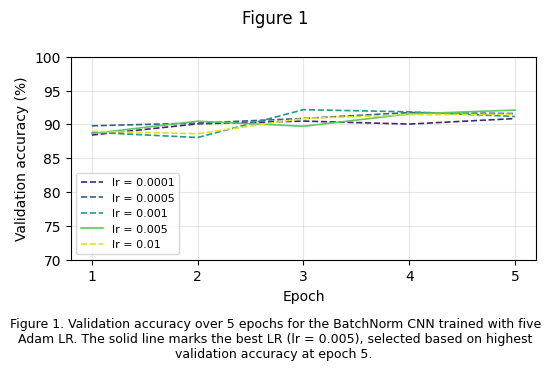

In [ ]:
# figure 1 learning rate sweep
# LR sweep for optimal data for Adam optimiser.
# Strategy: train BatchNorm CNN for LR_EPOCHS (5) epochs with each
# candidate LR and record validation accuracy at every epoch.
# the LR that achieves the highest final-epoch validation accuracy is selected
# Five candidate LRs spanning three decades are tested:
LEARNING_RATES = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
LR_EPOCHS = 5

# storaing validation accuracy history
lr_validation_accuracy_histories = {}

# Shared loss function used across all LR experiments
criterion = nn.CrossEntropyLoss()

for lr in LEARNING_RATES:
    model_lr = CNN(use_bn=True).to(device)

    opt_lr = optim.Adam(model_lr.parameters(), lr=lr)

    validation_accuracy = []

    print(f"\nLR = {lr}")
    for epoch in range(1, LR_EPOCHS + 1):
        # Train for one epoch with weights updated
        train_one_epoch(model_lr, training_loader, criterion, opt_lr)

        # Evaluate on the validation set without weight update
        _, v_acc = evaluate(model_lr, validation_loader, criterion)
        validation_accuracy.append(v_acc * 100)
        print(f"  epoch {epoch}/{LR_EPOCHS}  val acc: {v_acc*100:.1f}%")

    # Save this LR accuracy for plotting
    lr_validation_accuracy_histories[lr] = validation_accuracy

# Select the LR with the highest validation accuracy at the final epoch.
# lambda extracts the last element of each accuracy list.
BEST_LR = max(LEARNING_RATES, key=lambda r: lr_validation_accuracy_histories[r][-1])
print(f"\nBest LR: {BEST_LR}  (val acc = {lr_validation_accuracy_histories[BEST_LR][-1]:.1f}% at epoch {LR_EPOCHS})")

# Figure 1: LR search validation accuracy curves
figWidth = 14.
figHeight = 8.
fig, ax = plt.subplots(figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 1')

colors = plt.cm.viridis([0.1, 0.3, 0.55, 0.75, 0.95])

for (lr, accs), col in zip(lr_validation_accuracy_histories.items(), colors):
    ax.plot(range(1, LR_EPOCHS + 1), accs,
            linewidth=1.2,
            color=col,
            label=f'lr = {lr}',
            linestyle='-' if lr == BEST_LR else '--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation accuracy (%)')
ax.set_ylim([70, 100])
ax.xaxis.set_ticks(range(1, LR_EPOCHS + 1))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

txt = (f"Figure 1. Validation accuracy over {LR_EPOCHS} epochs for the BatchNorm CNN "
       f"trained with five Adam LR. The solid line marks the best LR "
       f"(lr = {BEST_LR}), selected based on highest validation accuracy at epoch {LR_EPOCHS}. ")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# Full training for baseline and BatchNorm models
# Two models are trained and compared:
#   • Baseline (use_bn=False): no BatchNorm — shows the unregularised baseline.
#   • BatchNorm  (use_bn=True): BatchNorm after every conv layer

def train_model(use_bn, n_epochs=15, lr=1e-3):
    """
    Train a CNN classifier and return the trained model and training history.
    Parameter:
    use_bn : bool, whether or not to include BatchNorm layers
    n_epochs: int,the total number of full passes over the training data
    lr: float, Adam learning rate

    Returns:
    model, trained CNN instance (on device)
    history, 'training_loss', 'validation_loss', 'training_accuracy', 'validation_accuracy'
    """
    # using GPU
    model = CNN(use_bn=use_bn).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # __init__ialise history dict accumulator
    history = {
        'training_loss':     [],
        'validation_loss': [],
        'training_accuracy': [],
        'validation_accuracy':    []
    }

    name = "BatchNorm" if use_bn else "Baseline (no BN)"
    print(f"\nTraining: {name}  lr={lr}")

    for epoch in range(1, n_epochs + 1):
        # Training step using forward pass, backprop, weight update
        t_loss, t_acc = train_one_epoch(model, training_loader, criterion, optimizer)

        # Validation step using forward pass only to detect overfitting
        v_loss, v_acc = evaluate(model, validation_loader, criterion)

        history['training_loss'].append(t_loss)
        history['validation_loss'].append(v_loss)
        history['training_accuracy'].append(t_acc)
        history['validation_accuracy'].append(v_acc)

        print(f"epoch {epoch:2d}/{n_epochs}"
              f"train {t_loss:.4f} / {t_acc*100:.1f}%  |  "
              f"val {v_loss:.4f} / {v_acc*100:.1f}%")

    return model, history


# run training with 15 epoch provides a long enough horizon to see convergence differences between the two variants.
N_EPOCHS = 15
model_baseline, hist_baseline = train_model(use_bn=False, n_epochs=N_EPOCHS, lr=BEST_LR)
model_bn, hist_bn = train_model(use_bn=True, n_epochs=N_EPOCHS, lr=BEST_LR)



Training: Baseline (no BN)  lr=0.005
  epoch  1/15  train 0.6133 / 77.5%  |  val 0.3945 / 85.8%
  epoch  2/15  train 0.3583 / 86.9%  |  val 0.3160 / 88.4%
  epoch  3/15  train 0.3166 / 88.4%  |  val 0.3277 / 87.9%
  epoch  4/15  train 0.2938 / 89.1%  |  val 0.3069 / 89.0%
  epoch  5/15  train 0.2794 / 89.7%  |  val 0.3160 / 88.7%
  epoch  6/15  train 0.2649 / 90.2%  |  val 0.2832 / 89.8%
  epoch  7/15  train 0.2568 / 90.5%  |  val 0.2925 / 89.8%
  epoch  8/15  train 0.2517 / 90.7%  |  val 0.3191 / 88.9%
  epoch  9/15  train 0.2454 / 90.9%  |  val 0.3139 / 89.2%
  epoch 10/15  train 0.2387 / 91.1%  |  val 0.2967 / 89.5%
  epoch 11/15  train 0.2301 / 91.5%  |  val 0.3199 / 88.9%
  epoch 12/15  train 0.2290 / 91.5%  |  val 0.3165 / 89.0%
  epoch 13/15  train 0.2222 / 91.7%  |  val 0.2975 / 89.7%
  epoch 14/15  train 0.2223 / 91.8%  |  val 0.3211 / 89.4%
  epoch 15/15  train 0.2201 / 92.0%  |  val 0.3016 / 89.8%

Training: BatchNorm  lr=0.005
  epoch  1/15  train 0.4338 / 84.0%  |  val 0.

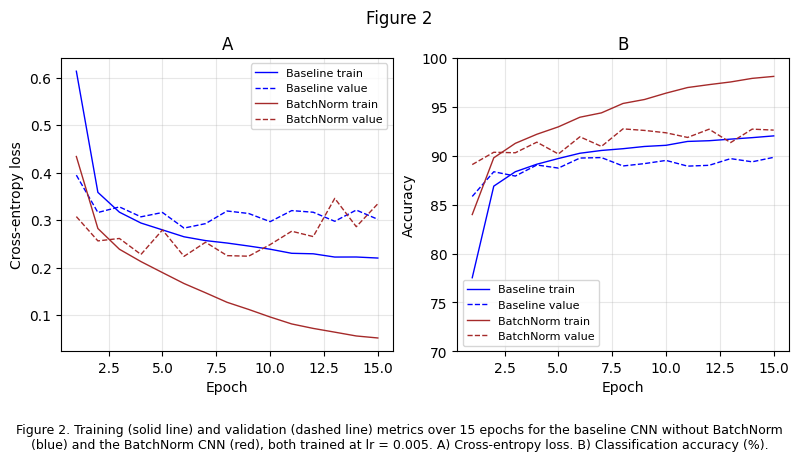

In [ ]:
# Figure 2 loss and accuracy curves
# Two-panel figure comparing the baseline and BatchNorm models over the 15 epochs.
# Panel A: cross entropy loss
# Panel B: classification accuracy in %
# Gaps between training (solid lines) and validation (dashed lines) indicates the degree of overfitting.

epochs = range(1, N_EPOCHS + 1)

figWidth = 20.
figHeight = 10.
fig, axs = plt.subplots(1, 2, constrained_layout=True,
figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 2')

# Panel A: Cross entropy loss
axs[0].set_title('A')
axs[0].plot(epochs, hist_baseline['training_loss'], color='blue',  linestyle='-', linewidth=1.0, label='Baseline train')
axs[0].plot(epochs, hist_baseline['validation_loss'], color='blue',  linestyle='--', linewidth=1.0, label='Baseline val')
axs[0].plot(epochs, hist_bn['training_loss'], color='brown', linestyle='-', linewidth=1.0, label='BatchNorm train')
axs[0].plot(epochs, hist_bn['validation_loss'], color='brown', linestyle='--', linewidth=1.0, label='BatchNorm val')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Cross-entropy loss')
axs[0].legend(fontsize=8)
axs[0].grid(True, alpha=0.3)

# Panel B: Classification accuracy
axs[1].set_title('B')
axs[1].plot(epochs, [v*100 for v in hist_baseline['training_accuracy']], color='blue',  linestyle='-', linewidth=1.0, label='Baseline train')
axs[1].plot(epochs, [v*100 for v in hist_baseline['validation_accuracy']], color='blue',  linestyle='--', linewidth=1.0, label='Baseline val')
axs[1].plot(epochs, [v*100 for v in hist_bn['training_accuracy']], color='brown', linestyle='-', linewidth=1.0, label='BatchNorm train')
axs[1].plot(epochs, [v*100 for v in hist_bn['validation_accuracy']], color='brown', linestyle='--', linewidth=1.0, label='BatchNorm val')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_ylim([70, 100])
axs[1].legend(fontsize=8)
axs[1].grid(True, alpha=0.3)

# Figure caption
txt = (f"Figure 2. Training (solid line) and validation (dashed line) metrics over {N_EPOCHS} epochs "
       f"for the baseline CNN without BatchNorm (blue) and the BatchNorm CNN (brown), "
       f"both trained at lr = {BEST_LR}. "
       f"A) Cross-entropy loss. B) Classification accuracy (%).")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.show()


Test-set results:
  Baseline CNN  — loss: 0.3197   accuracy: 89.13%
  BatchNorm CNN — loss: 0.3787   accuracy: 91.99%

Per-class test accuracy (BatchNorm CNN):
  T-shirt/top    : 91.2%
  Trouser        : 98.3%
  Pullover       : 90.8%
  Dress          : 91.9%
  Coat           : 89.9%
  Sandal         : 94.4%
  Shirt          : 70.8%
  Sneaker        : 97.2%
  Bag            : 97.9%
  Ankle boot     : 97.5%


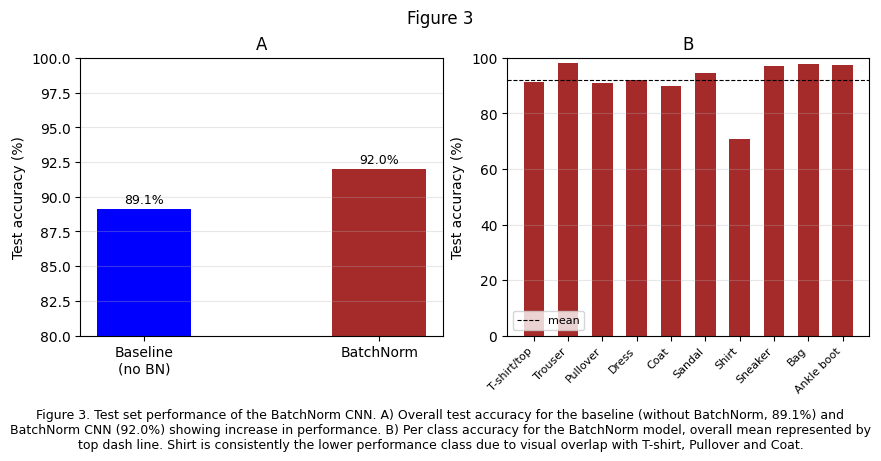

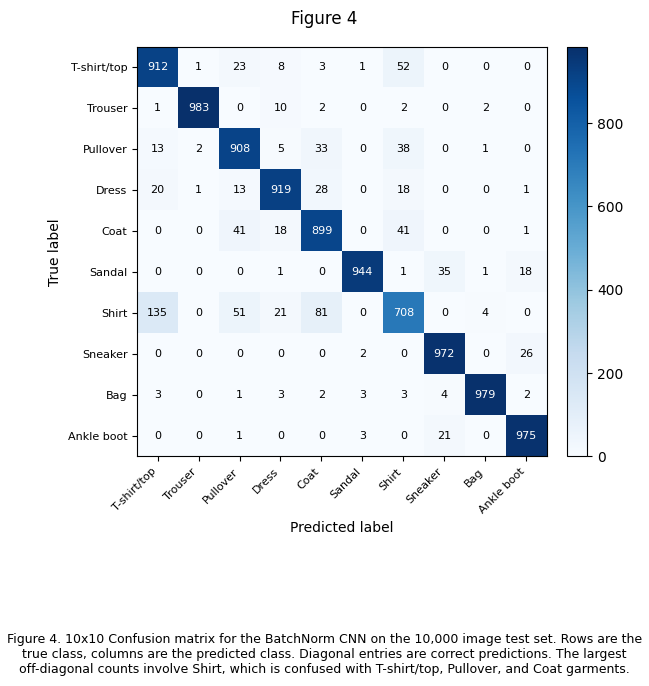

In [ ]:
# Test set evaluation and per class analysis
# figures 3 bar charts comparing overall and per-class accuracy & 4 confusion matrix
# unbiased and unchange data for training and validation, or the LR search.

criterion = nn.CrossEntropyLoss()

# evaluate() returns mean_loss and accuracy_fraction over the full loader
test_loss_bl, test_acc_bl = evaluate(model_baseline, testing_loader, criterion)
test_loss_bn, test_acc_bn = evaluate(model_bn, testing_loader, criterion)

print("Test-set results:")
print(f"  Baseline CNN loss: {test_loss_bl:.4f} accuracy: {test_acc_bl*100:.2f}%")
print(f"  BatchNorm CNN loss: {test_loss_bn:.4f} accuracy: {test_acc_bn*100:.2f}%")

# Per class accuracy and confusion matrix data collection
# second pass over the test set with the BatchNorm model
# collecting aggregate counts per class and all predicted and true labels.

correct_per_class = {c: 0 for c in CLASSES}
total_per_class = {c: 0 for c in CLASSES}
all_preds, all_labels_list = [], []

model_bn.eval()
with torch.no_grad():
    for images, labels in testing_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_bn(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())

        # Tally correct predictions per class
        for lbl, pred in zip(labels, predicted):
            cls = CLASSES[lbl.item()]
            total_per_class[cls] += 1
            if lbl == pred:
                correct_per_class[cls] += 1

# count covert to percentage for each class
per_class_acc = [100 * correct_per_class[c] / total_per_class[c] for c in CLASSES]

print("\nPer-class test accuracy (BatchNorm CNN):")
for cls, acc in zip(CLASSES, per_class_acc):
    print(f" {cls:15s}: {acc:.1f}%")

# Figure 3: Overall ablation bar chart + per-class accuracy
# Panel A compares the two models' overall test accuracy.
# Panel B shows per-class accuracy for the BatchNorm model, revealing which
# clothing categories are hardest to classify.

figWidth = 22.
figHeight = 10.
fig, axs = plt.subplots(1, 2, constrained_layout=True,
                         figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 3')

# Panel A: Overall test accuracy
axs[0].set_title('A')
bars = axs[0].bar(['Baseline\n(no BN)', 'BatchNorm'],
                   [test_acc_bl * 100, test_acc_bn * 100],
                   color=['blue', 'brown'], width=0.4)
axs[0].set_ylabel('Test accuracy (%)')
axs[0].set_ylim([80, 100])

for bar, val in zip(bars, [test_acc_bl * 100, test_acc_bn * 100]):
    axs[0].text(bar.get_x() + bar.get_width() / 2, val + 0.2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axs[0].grid(True, axis='y', alpha=0.3)

# Panel B: Per-class accuracy (BN)
axs[1].set_title('B')
x = np.arange(len(CLASSES))
axs[1].bar(x, per_class_acc, color='brown', width=0.6)
axs[1].set_xticks(x)
axs[1].set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
axs[1].set_ylabel('Test accuracy (%)')
axs[1].set_ylim([0, 100])

# Horizontal marks the overall mean test accuracy
axs[1].axhline(test_acc_bn * 100, color='black', linestyle='--', linewidth=0.8, label='mean')
axs[1].legend(fontsize=8)
axs[1].grid(True, axis='y', alpha=0.3)

txt = (f"Figure 3. Test set performance of the BatchNorm CNN. "
       f"A) Overall test accuracy for the baseline (without BatchNorm, {test_acc_bl*100:.1f}%) "
       f"and BatchNorm CNN ({test_acc_bn*100:.1f}%) showing increase in performance. "
       f"B) Per class accuracy for the BatchNorm model, overall mean represented by top dash line. "
       f"Shirt is consistently the lower performance class due to visual overlap with T-shirt, Pullover and Coat.")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.show()

# Figure 4: Confusion matrix (10x10)
# Diagonal entries are correct predictions and off-diagonal entries are errors.

cm = confusion_matrix(all_labels_list, all_preds)
figWidth = 16.
figHeight = 14.
fig, ax = plt.subplots(figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 4')

im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=8,
                color='white' if cm[i, j] > thresh else 'black')

tick_marks = np.arange(len(CLASSES))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(CLASSES, fontsize=8)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')

txt = ("Figure 4. 10x10 Confusion matrix for the BatchNorm CNN on the 10000 image test set. "
       "Rows are the true class, columns are the predicted class. "
       "Diagonal entries are correct predictions. "
       "The largest off-diagonal counts involve Shirt, which is confused with "
       "T-shirt/top, Pullover, and Coat garments.")
plt.figtext(0.5, -0.22, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.tight_layout()
plt.show()


# TASK 2 <ignore>

*Replace this text with your report for Task 2*

In [15]:
# a unconditional Generative Adversarial Network (GAN) for Fashion MNIST Image Generation
# A GAN consists of two networks trained in opposition:
#   • Generator (G): takes a random noise vector z ~ N(0,1) and produces a fake generated image
#   • Discriminator (D): given an image, outputs P(image is real) ∈ (0, 1)

# GAN specific DataLoader
# The Generator uses Tanh for final activation.
# real training images are re-normalised with mean=0.5 and
# std=0.5, mapping the ToTensor() [0, 1] range to [-1, 1].

gan_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])
gan_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                                 download=False, transform=gan_transform)
gan_loader = DataLoader(gan_dataset, batch_size=64, shuffle=True, num_workers=0)

# Latent dimension: the length of the noise vector fed to the Generator.
LATENT_DIM = 100

# Generator maps z ∈ R^LATENT_DIM to a 1×28×28 image in [-1, 1].
# linear projection → reshape to spatial tensor → two transposed convolutions.
# Transposed convolutions upsample the spatial dimensions [128, 7, 7] → [64, 14, 14] → [1, 28, 28]

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        # Project noise vector to a spatial feature tensor.
        self.project = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU()
        )
        # First upsample block: batch [128, 7, 7] → [64, 14, 14]
        # ConvTranspose2d with stride=2 doubles spatial dimensions.
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        # Second upsample block: batch [64, 14, 14] → [1, 28, 28]
        # Tanh maps output to [-1, 1] to match the normalised real image range.
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.project(z)
        x = x.view(x.size(0), 128, 7, 7)
        x = self.up1(x)
        x = self.up2(x)
        return x

# Discriminator maps a 1×28×28 image to a scalar ∈ (0, 1) using Sigmoid.
# two strided convolutions → flatten → linear → sigmoid.
# LeakyReLU (negative slope 0.2) is used instead of ReLU to allow gradients to flow even for negative activations, reducing the risk of dead neurons in D.

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Downsample: batch [1, 28, 28] → [64, 14, 14]
        # No BN on the first layer standardised DCGAN architecture.
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2)
        )
        # Downsample: batch [64, 14, 14] → [128, 7, 7]
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2)
        )
        # Classification head: batch 128*7*7 = 6272 → batch [1]
        # Sigmoid maps the logit to a probability in (0, 1).
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x


# Instantiate models in GPU
G = Generator(LATENT_DIM).to(device)
D = Discriminator().to(device)

# BCE loss
criterion_gan = nn.BCELoss()

# Adam with lr=2e-4 and beta1=0.5 reducing beta1 from the default (0.9) to 0.5 gives less momentum
GAN_LR = 2e-4
G_optim = optim.Adam(G.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
D_optim = optim.Adam(D.parameters(), lr=GAN_LR, betas=(0.5, 0.999))

# Fixed noise with a constant set of 64 z vectors used for visualisation.
fixed_noise = torch.randn(64, LATENT_DIM, device=device)

# GAN training loop
# Each epoch alternates between:
#   1. One D update per batch
#   2. One G update per batch
GAN_EPOCHS = 30

g_losses = []
d_losses = []

print(f"Training GAN for {GAN_EPOCHS} epochs on {device}...")

for epoch in range(1, GAN_EPOCHS + 1):
    running_d, running_g, n_batches = 0.0, 0.0, 0

    for real_images, _ in gan_loader:
        bs = real_images.size(0)
        real_images = real_images.to(device)

        real_labels = torch.ones(bs, 1, device=device)
        fake_labels = torch.zeros(bs, 1, device=device)

        # training discriminator updating D first each step
        D_optim.zero_grad()

        # D on real images, targeting 1 as real
        d_real_out = D(real_images)
        d_loss_real = criterion_gan(d_real_out, real_labels)

        # generate fake images
        z = torch.randn(bs, LATENT_DIM, device=device)
        fake_images = G(z)
        d_fake_out = D(fake_images.detach())
        d_loss_fake = criterion_gan(d_fake_out, fake_labels)

        # Total D loss: average of real and fake losses
        d_loss = (d_loss_real + d_loss_fake) / 2
        d_loss.backward()
        D_optim.step()

        # training generator updating G each step
        G_optim.zero_grad()
        d_out_for_g = D(fake_images)
        g_loss = criterion_gan(d_out_for_g, real_labels)
        g_loss.backward()
        G_optim.step()

        running_d += d_loss.item()
        running_g += g_loss.item()
        n_batches += 1

    # Record epoch-level averages
    d_losses.append(running_d / n_batches)
    g_losses.append(running_g / n_batches)
    print(f"epoch {epoch:2d}/{GAN_EPOCHS}  D loss: {d_losses[-1]:.4f}  G loss: {g_losses[-1]:.4f}")

print("\nGAN training finished.")


Training GAN for 30 epochs on cpu...
epoch  1/30  D loss: 0.1024  G loss: 3.4327
epoch  2/30  D loss: 0.1169  G loss: 3.1572
epoch  3/30  D loss: 0.2092  G loss: 2.4882
epoch  4/30  D loss: 0.2291  G loss: 2.3365
epoch  5/30  D loss: 0.2340  G loss: 2.3567
epoch  6/30  D loss: 0.2348  G loss: 2.3916
epoch  7/30  D loss: 0.2230  G loss: 2.4921
epoch  8/30  D loss: 0.2183  G loss: 2.5868
epoch  9/30  D loss: 0.2133  G loss: 2.6426
epoch 10/30  D loss: 0.2153  G loss: 2.6670
epoch 11/30  D loss: 0.2126  G loss: 2.6974
epoch 12/30  D loss: 0.2073  G loss: 2.7409
epoch 13/30  D loss: 0.2033  G loss: 2.7803
epoch 14/30  D loss: 0.2027  G loss: 2.8199
epoch 15/30  D loss: 0.2010  G loss: 2.8505
epoch 16/30  D loss: 0.2010  G loss: 2.8741
epoch 17/30  D loss: 0.1947  G loss: 2.9315
epoch 18/30  D loss: 0.1963  G loss: 2.9497
epoch 19/30  D loss: 0.1946  G loss: 2.9713
epoch 20/30  D loss: 0.1904  G loss: 3.0071
epoch 21/30  D loss: 0.1880  G loss: 3.0455
epoch 22/30  D loss: 0.1936  G loss: 3.

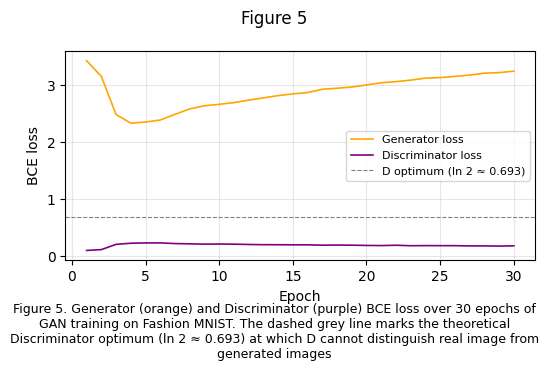

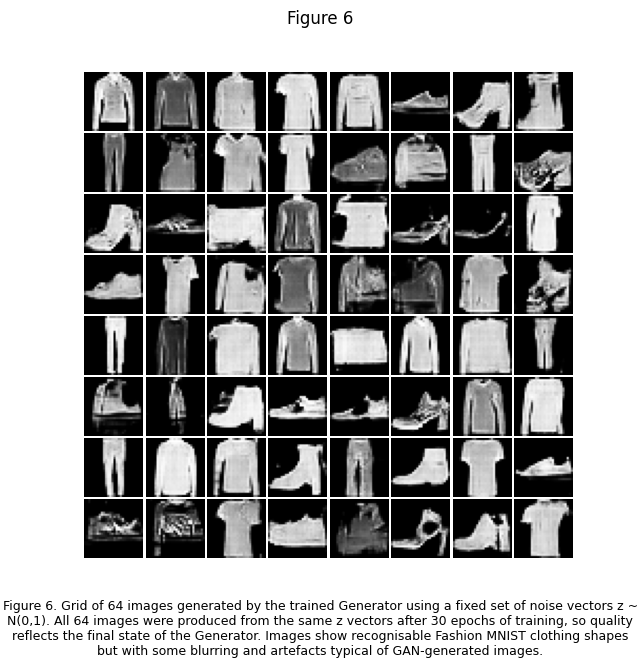

In [16]:
# Figure 5: GAN training loss curve
# small divergence between G and D loss indicates training stability and vice versa

epochs_gan = range(1, GAN_EPOCHS + 1)

figWidth  = 14.
figHeight = 8.
fig, ax = plt.subplots(figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 5')

# plotting G and D losses for direct comparison
ax.plot(epochs_gan, g_losses, color='orange', linewidth=1.2, label='Generator loss')
ax.plot(epochs_gan, d_losses, color='purple', linewidth=1.2, label='Discriminator loss')

# Theoretical D optimum, when ln(2) ≈ 0.693 when D cannot distinguish real from fake better than chance.
ax.axhline(np.log(2), color='grey', linestyle='--', linewidth=0.8, label='D optimum (ln 2 ≈ 0.693)')

ax.set_xlabel('Epoch')
ax.set_ylabel('BCE loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

txt = (f"Figure 5. Generator (orange) and Discriminator (purple) BCE loss over {GAN_EPOCHS} epochs of GAN training on Fashion MNIST. "
       f"The dashed grey line marks the theoretical Discriminator optimum (ln 2 ≈ 0.693) "
       f"at which D cannot distinguish real image from generated images")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.tight_layout()
plt.show()

# Figure 6: Grid of generated images
# Pass the fixed noise batch through the trained Generator to produce 64 images.

G.eval()
with torch.no_grad():
    gen_images = G(fixed_noise)

# Rescale from [-1, 1] back to [0, 1] for display
gen_images = (gen_images + 1) / 2

figWidth  = 16.
figHeight = 16.
fig, axes = plt.subplots(8, 8, figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 6')

for idx, ax in enumerate(axes.flat):
    img = gen_images[idx].squeeze().cpu().numpy()
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)

txt = (f"Figure 6. Grid of 64 images generated by the trained Generator using a fixed set of noise vectors z ~ N(0,1). "
       f"All 64 images were produced from the same z vectors after {GAN_EPOCHS} epochs of training, so quality reflects the final "
       f"state of the Generator. Images show recognisable Fashion MNIST clothing shapes "
       f"but with some blurring and artefacts typical of GAN-generated images.")
plt.figtext(0.5, -0.04, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.show()


Real images, mean D score: 0.625  (std: 0.277)
Fake images, mean D score: 0.116  (std: 0.152)


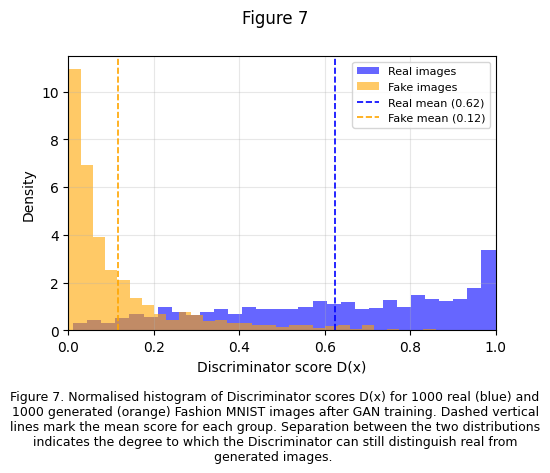

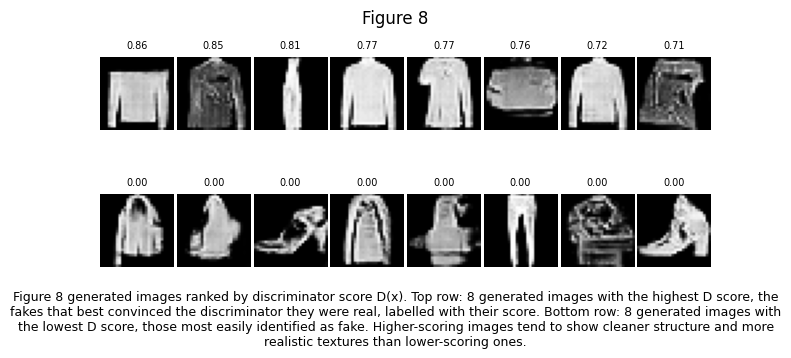

In [22]:
# Figures 7 & 8 discriminator quality score analysis

D.eval()
G.eval()

real_scores_list = []
fake_scores_list = []
fake_images_store = None

with torch.no_grad():
    # real image scores
    n_collected = 0
    for real_imgs, _ in gan_loader:
        real_imgs = real_imgs.to(device)
        scores = D(real_imgs).squeeze().cpu().numpy()
        real_scores_list.extend(scores.tolist())
        n_collected += real_imgs.size(0)
        if n_collected >= 1000:
            break

    # fake image scores
    # generate 1000 fake images in forward pass and score them all with D
    z_large = torch.randn(1000, LATENT_DIM, device=device)
    fake_images_all = G(z_large)
    fake_scores_arr = D(fake_images_all).squeeze().cpu().numpy()
    fake_scores_list.extend(fake_scores_arr.tolist())
    fake_images_store = fake_images_all.cpu()

real_scores = np.array(real_scores_list[:1000])
fake_scores = np.array(fake_scores_list)

print(f"Real images, mean D score: {real_scores.mean():.3f}  (std: {real_scores.std():.3f})")
print(f"Fake images, mean D score: {fake_scores.mean():.3f}  (std: {fake_scores.std():.3f})")

# Figure 7: D score distributions
figWidth  = 14.
figHeight = 12.   # taller figure so caption clears the x-axis label
fig, ax = plt.subplots(figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 7')

# Overlapping histograms if density=True normalises both to the same y scale
ax.hist(real_scores, bins=30, alpha=0.6, color='blue',   label='Real images', density=True)
ax.hist(fake_scores, bins=30, alpha=0.6, color='orange', label='Fake images', density=True)

ax.axvline(real_scores.mean(), color='blue',   linestyle='--', linewidth=1.2,
           label=f'Real mean ({real_scores.mean():.2f})')
ax.axvline(fake_scores.mean(), color='orange', linestyle='--', linewidth=1.2,
           label=f'Fake mean ({fake_scores.mean():.2f})')

ax.set_xlabel('Discriminator score D(x)')
ax.set_ylabel('Density')
ax.set_xlim([0, 1])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

txt = ("Figure 7. Normalised histogram of Discriminator scores D(x) for 1000 real (blue) "
       "and 1000 generated (orange) Fashion MNIST images after GAN training. "
       "Dashed vertical lines mark the mean score for each group. "
       "Separation between the two distributions indicates the degree to which the "
       "Discriminator can still distinguish real from generated images. ")


plt.subplots_adjust(bottom=0.3)
plt.figtext(0.5, 0.03, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.show()

# Figure 8: Top-8 and bottom-8 generated images by D score
# rank all generated images by their D score.
# top 8 score = discriminator mostly convinced they are real.
# bottom 8 score = discriminator mostly convinced they are fake.

sorted_idx = np.argsort(fake_scores)
top8_idx = sorted_idx[-8:][::-1]
bottom8_idx = sorted_idx[:8]

def rescale(t):
    """Rescale a Tanh-output image tensor from [-1,1] to [0,1] for imshow."""
    return (t + 1) / 2

figWidth = 20.
figHeight = 8.
fig, axs = plt.subplots(2, 8, figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 8')

for col, (top_i, bot_i) in enumerate(zip(top8_idx, bottom8_idx)):
    # Top row: highest D scored generated images
    img_top = rescale(fake_images_store[top_i]).squeeze().numpy()
    axs[0, col].imshow(img_top, cmap='gray', vmin=0, vmax=1)
    axs[0, col].set_title(f'{fake_scores[top_i]:.2f}', fontsize=7)
    axs[0, col].axis('off')

    # Bottom row: lowest D scored generated images
    img_bot = rescale(fake_images_store[bot_i]).squeeze().numpy()
    axs[1, col].imshow(img_bot, cmap='gray', vmin=0, vmax=1)
    axs[1, col].set_title(f'{fake_scores[bot_i]:.2f}', fontsize=7)
    axs[1, col].axis('off')

axs[0, 0].set_ylabel('Top 8\n(highest D score)', fontsize=7)
axs[1, 0].set_ylabel('Bottom 8\n(lowest D score)', fontsize=7)

plt.subplots_adjust(wspace=0.05, hspace=0.3)

txt = ("Figure 8 generated images ranked by discriminator score D(x). "
       "Top row: 8 generated images with the highest D score, the fakes that best "
       "convinced the discriminator they were real, labelled with their score. "
       "Bottom row: 8 generated images with the lowest D score, those most "
       "easily identified as fake. Higher-scoring images tend to show cleaner structure "
       "and more realistic textures than lower-scoring ones.")
plt.figtext(0.5, -0.08, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.show()


Predicted class distribution of generated images:
  T-shirt/top    : 14.2%
  Trouser        : 10.5%
  Pullover       : 12.6%
  Dress          : 9.8%
  Coat           : 8.8%
  Sandal         : 5.5%
  Shirt          : 7.0%
  Sneaker        : 9.4%
  Bag            : 8.3%
  Ankle boot     : 13.9%


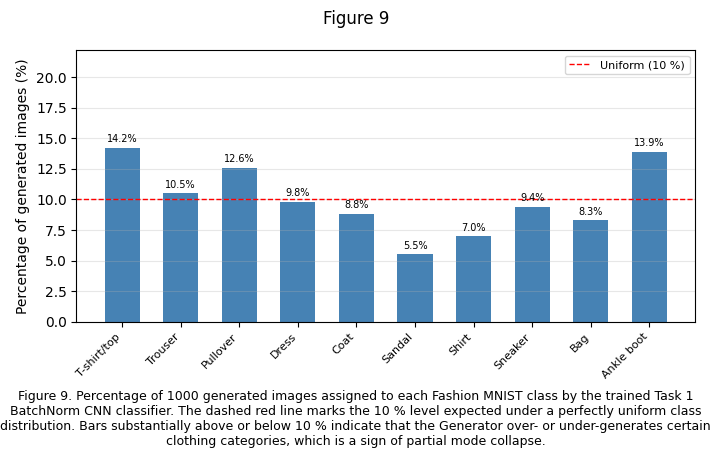

In [ ]:
# Figure 9: Class distribution of generated images as classified by the Task 1 CNN
# each of the 10 Fashion MNIST classes should appear ~10% of the time.
# A deviation from uniform  reveals which classes G over/undergenerates
# The trained Task 1 BatchNorm classifier (model_bn) expects images normalised
# with mean=0.2860, std=0.3530. G outputs in [-1, 1] (Tanh)
CLASSIFIER_MEAN = 0.2860
CLASSIFIER_STD  = 0.3530

N_GEN = 1000

model_bn.eval()
G.eval()

with torch.no_grad():
    # sample N_GEN noise vectors and generate images
    z_cls = torch.randn(N_GEN, LATENT_DIM, device=device)
    gen_cls = G(z_cls)

    # rescale from [-1, 1] to [0, 1]
    gen_cls_01 = (gen_cls + 1.0) / 2.0

    # re-normalise to match the classifier's expected input distribution
    gen_cls_norm = (gen_cls_01 - CLASSIFIER_MEAN) / CLASSIFIER_STD

    # forward pass through the Task 1 classifier to get class predictions
    logits = model_bn(gen_cls_norm)
    predicted = torch.argmax(logits, dim=1).cpu().numpy()

class_counts = np.array([(predicted == i).sum() for i in range(len(CLASSES))])
class_pcts = class_counts / N_GEN * 100

print("Predicted class distribution of generated images:")
for cls, pct in zip(CLASSES, class_pcts):
    print(f"  {cls:15s}: {pct:.1f}%")

figWidth  = 18.
figHeight = 10.
fig, ax = plt.subplots(figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 9')

x = np.arange(len(CLASSES))
bars = ax.bar(x, class_pcts, color='steelblue', width=0.6)

ax.axhline(100.0 / len(CLASSES), color='red', linestyle='--', linewidth=1.0,
           label='Uniform (10 %)')

for bar, pct in zip(bars, class_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Percentage of generated images (%)')
ax.set_ylim([0, max(class_pcts) + 8])
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)

txt = (f"Figure 9. Percentage of {N_GEN} generated images assigned to each of the 10 Fashion MNIST class by the trained Task 1 BatchNorm CNN classifier. "
       f"The red line marks the 10 % level expected under a perfectly uniform class distribution. "
       f"Bars substantially above or below 10 % indicate that the Generator over/undergenerates "
       f"certain clothing categories, which is a sign of partial mode collapse.")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.tight_layout()
plt.show()


# TASK 3 <ignore>

*Replace this text with your report for Task 3*

In [ ]:
###
### Use this code cell for Task 3. You may create code cells immediately 
### after this one if you need to.
###

## References <ignore>

*Replace this text with full references for any published articles that you cite in the report*